# Hotel Booking Prediction
### Homework week09 without changing text description please see only code

- Hotel reservation booking data analytics involves the process of collecting, analyzing, and interpreting data related to hotel reservations to make informed decisions.
- This practice can enhance operational efficiency, improve customer satisfaction, and increase revenue.
- Data analytics can provide valuable insights into customer behavior, booking patterns, and market trends.

https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset/data
https://www.kaggle.com/code/dinachanthan/hotel-booking-reservation-predition

This notebook aim to build a machine learning model to predict hotel reservation cancellations that involved several steps.

1. Data Preprocessing:
- Clean the data (handle missing values, correct data types, etc.).
- Encode categorical variables.
- Normalize/standardize the numerical features if necessary.
2. Feature Selection:
- Identify which features might be important for predicting cancellations.
3. Model Selection:
- Choose an appropriate machine learning algorithm (e.g., logistic regression, decision tree, random forest, etc.).
4. Model Training:
- Split the data into training and testing sets.
- Train the model on the training data.
5. Model Evaluation:
- Evaluate the model using the testing data (e.g., accuracy, precision, recall, F1 score).
6. Hyperparameter Tuning:
- Optimize the model parameters for better performance.
7. Model Deployment:
- Prepare the model for deployment (e.g., saving the model, creating an API).

In [1]:
#Install gradio: Gradio is the fastest way to demo your machine learning model with a friendly web interface so that anyone can use it, anywhere!
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.7/56.7 MB 4.0 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 4.8 MB/s eta 0:00:0000:010:01

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


#Importing Library

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import gradio as gr
import seaborn as sns
import matplotlib.pyplot as plt

/Users/rattanak/Documents/Sample_Projects/python_for_cs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#Loading Dataset

In [122]:
# loading dataset
data = pd.read_csv('hotel_bookings.csv')

#Exploratory Data Analysis - EDA

In [123]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [98]:
data.head()
data.shape

(119390, 32)

##About this file

**Add Suggestion**

- The file contains the different attributes of customers' reservation details. The detailed data dictionary is given below.

**Data Dictionary**

- **Booking_ID**: unique identifier of each booking
- **no_of_adults**: Number of adults
- **no_of_children**: Number of Children
- **no_of_weekend_nights**: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
- **no_of_week_nights**: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
- **type_of_meal_plan**: Type of meal plan booked by the customer:
- **required_car_parking_space**: Does the customer require a car parking space? (0 - No, 1- Yes)
- **room_type_reserved**: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
- **lead_time**: Number of days between the date of booking and the arrival date
- **arrival_year**: Year of arrival date
- **arrival_month**: Month of arrival date
- **arrival_date**: Date of the month
- **market_segment_type**: Market segment designation.
- **repeated_guest**: Is the customer a repeated guest? (0 - No, 1- Yes)
- **no_of_previous_cancellations**: Number of previous bookings that were canceled by the customer prior to the current booking
- **no_of_previous_bookings_not_canceled**: Number of previous bookings not canceled by the customer prior to the current booking
- **avg_price_per_room**: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
- **no_of_special_requests**: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
- **booking_status**: Flag indicating if the booking was canceled or not.

In [124]:
# Descriptive statistic on dataset on numerical columns
data[['hotel', 'is_canceled', 'lead_time',
    'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number',
    'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies',
    'meal', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']].describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


#Data Preprocessing

In [125]:
# Dictionaries to store encoding and decoding maps
encoding_maps = {}
decoding_maps = {}

# Encode categorical variables
label_encoders = {}
for column in ['hotel', 'market_segment', 'arrival_date_month', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

    # Create encoding map
    encoding_map = {original: encoded for original, encoded in zip(label_encoders[column].classes_, label_encoders[column].transform(label_encoders[column].classes_))}
    encoding_maps[column] = encoding_map

    # Create decoding map
    decoding_map = {encoded: original for original, encoded in encoding_map.items()}
    decoding_maps[column] = decoding_map

In [126]:
# Print the encoding and decoding maps
print("Encoding Maps:", encoding_maps)

print("\nDecoding Maps:", decoding_maps)

Encoding Maps: {'hotel': {'City Hotel': 0, 'Resort Hotel': 1}, 'market_segment': {'Aviation': 0, 'Complementary': 1, 'Corporate': 2, 'Direct': 3, 'Groups': 4, 'Offline TA/TO': 5, 'Online TA': 6, 'Undefined': 7}, 'arrival_date_month': {'April': 0, 'August': 1, 'December': 2, 'February': 3, 'January': 4, 'July': 5, 'June': 6, 'March': 7, 'May': 8, 'November': 9, 'October': 10, 'September': 11}, 'distribution_channel': {'Corporate': 0, 'Direct': 1, 'GDS': 2, 'TA/TO': 3, 'Undefined': 4}, 'reserved_room_type': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'L': 8, 'P': 9}, 'assigned_room_type': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10, 'P': 11}, 'deposit_type': {'No Deposit': 0, 'Non Refund': 1, 'Refundable': 2}, 'customer_type': {'Contract': 0, 'Group': 1, 'Transient': 2, 'Transient-Party': 3}}

Decoding Maps: {'hotel': {0: 'City Hotel', 1: 'Resort Hotel'}, 'market_segment': {0: 'Aviation', 1: 'Complementary', 2: 'Corporate'

In [102]:
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,0,342,2015,5,27,1,0,0,2,...,0,NaN,NaN,0,2,0.0,0,0,Check-Out,2015-07-01
1,1,0,737,2015,5,27,1,0,0,2,...,0,NaN,NaN,0,2,0.0,0,0,Check-Out,2015-07-01
2,1,0,7,2015,5,27,1,0,1,1,...,0,NaN,NaN,0,2,75.0,0,0,Check-Out,2015-07-02
3,1,0,13,2015,5,27,1,0,1,1,...,0,304.0,NaN,0,2,75.0,0,0,Check-Out,2015-07-02
4,1,0,14,2015,5,27,1,0,2,2,...,0,240.0,NaN,0,2,98.0,0,1,Check-Out,2015-07-03


#Feature & Target Selection

In [127]:
# Define features and target
data = data.drop(columns=['company', 'adr', 'reservation_status', 'country', 'meal', 'agent', 'reservation_status_date',
                           "arrival_date_week_number", "arrival_date_day_of_month", "days_in_waiting_list", "reservation_status", "total_of_special_requests"])

In [128]:
print(data.isna().sum())

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          4
babies                            0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
customer_type                     0
required_car_parking_spaces       0
dtype: int64


In [129]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Initialize the imputer
imputer = SimpleImputer(strategy='mean')

# Fit and transform the data
X_imputed = imputer.fit_transform(data)

# Convert the result back to a DataFrame with the original column names
X_imputed_df = pd.DataFrame(X_imputed, columns=data.columns)

In [130]:
y = X_imputed_df['is_canceled']
X = X_imputed_df.drop(columns=['is_canceled'])

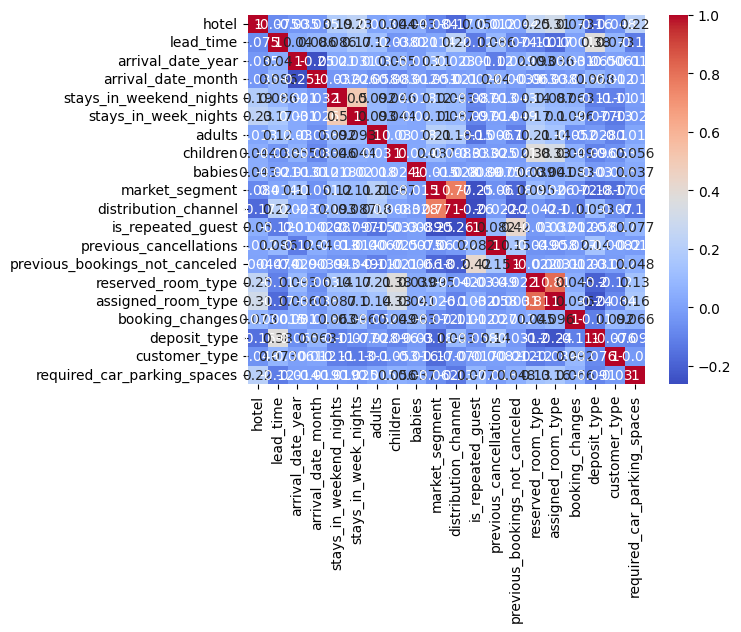

In [131]:
#Heatmap
# X = X.drop(columns=['is_canceled'])
# xy.columns
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.show()

#Split Train & Test Dataset

In [132]:
# Split the data into training and testing sets (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [140]:
# Show feature train
X_train.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,customer_type,required_car_parking_spaces
67702,0.0,64.0,2017.0,8.0,2.0,1.0,3.0,0.0,0.0,6.0,3.0,0.0,0.0,0.0,3.0,3.0,0.0,0.0,2.0,0.0
115851,0.0,34.0,2017.0,5.0,1.0,1.0,2.0,1.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
57345,0.0,8.0,2016.0,11.0,1.0,1.0,2.0,2.0,0.0,6.0,3.0,0.0,0.0,0.0,5.0,5.0,0.0,0.0,2.0,0.0
11622,1.0,251.0,2017.0,8.0,2.0,4.0,2.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,4.0,4.0,0.0,0.0,2.0,0.0
33333,1.0,23.0,2017.0,3.0,1.0,1.0,2.0,0.0,0.0,6.0,3.0,0.0,0.0,0.0,3.0,3.0,0.0,0.0,2.0,0.0


In [134]:
# Show target train
y_train.head(),

(67702     1.0
 115851    0.0
 57345     1.0
 11622     1.0
 33333     0.0
 Name: is_canceled, dtype: float64,)

In [135]:
# Show feature test
X_test.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,customer_type,required_car_parking_spaces
30946,1.0,203.0,2016.0,2.0,2.0,5.0,2.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,5.0,5.0,4.0,0.0,2.0,0.0
40207,0.0,82.0,2015.0,5.0,0.0,3.0,2.0,0.0,0.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
103708,0.0,25.0,2016.0,2.0,0.0,3.0,3.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,0.0,9.0,2.0,0.0,3.0,0.0
85144,0.0,1.0,2016.0,7.0,0.0,1.0,1.0,0.0,0.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
109991,0.0,70.0,2017.0,0.0,2.0,2.0,2.0,0.0,0.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0


In [136]:
# Show target test
y_test.head()

30946     0.0
40207     1.0
103708    0.0
85144     0.0
109991    0.0
Name: is_canceled, dtype: float64

#Model Training
##Train using Logistic Regression

In [137]:
# Train a logistic regression model
model = LogisticRegression(solver='saga', max_iter=1000)
model.fit(X_train, y_train)

/Users/rattanak/Documents/Sample_Projects/python_for_cs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=1000, solver='saga')

In [ ]:
#If you want to save the model for later use!
# import pickle

# with open("/content/sample_data/model.pkl", "wb") as f:
#     pickle.dump(model, f)

In [ ]:
#load a pretrained model
# with open("model.pkl", "rb") as f:
#     model = pickle.load(f)

##Model Evaluation

In [138]:
# Evaluate the model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.74      0.94      0.83     14907
         1.0       0.81      0.44      0.57      8971

    accuracy                           0.75     23878
   macro avg       0.77      0.69      0.70     23878
weighted avg       0.77      0.75      0.73     23878



a). Class-wise Metrics:

**Class 0:**

- Precision (0.74): Out of all instances predicted as class 0, 74% were correctly identified.
- Recall (0.58): Out of all actual instances of class 0, 56% were correctly predicted.
- F1-Score (0.65): This is the harmonic mean of precision and recall, indicating a balance between the two metrics.
- Support (2416): There are 2416 actual instances of class 0 in the dataset.

**Class 1:**

- Precision (0.81): Out of all instances predicted as class 1, 82% were correctly identified.
- Recall (0.90): Out of all actual instances of class 1, 90% were correctly predicted.
- F1-Score (0.85): This is the harmonic mean of precision and recall for class 1.
- Support (4839): There are 4839 actual instances of class 1 in the dataset.

**b). Overall Metrics:**

- Accuracy (0.79):

>The model correctly predicts the class for 81% of the instances in the dataset.

- Macro Average:

> - Precision (0.78): This is the unweighted average precision across all classes.
> - Recall (0.74): This is the unweighted average recall across all classes.
> - F1-Score (0.75): This is the unweighted average F1-score across all classes.

- Weighted Average:
> - Precision (0.79): This is the average precision weighted by the number of instances in each class.
> - Recall (0.79): This is the average recall weighted by the number of instances in each class.
> - F1-Score (0.79): This is the average F1-score weighted by the number of instances in each class.

**c). Summary:**

> - Performance on Class 0: The logistic regression model has a precision of 74% and recall of 58% for class 0, leading to an F1-score of 65%.
> - Performance on Class 1: The model performs better on class 1, with a precision of 81% and recall of 90%, resulting in an F1-score of 85%.
> - Overall Performance: The overall accuracy of the model is 79%. The macro average metrics indicate some imbalance in performance between classes, while the weighted averages reflect good overall performance, considering the distribution of the classes.

##Train using RandomRorest Classifier

In [141]:
# Train a Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

##evaluation

In [142]:
# Evaluate the model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87     14907
         1.0       0.80      0.73      0.76      8971

    accuracy                           0.83     23878
   macro avg       0.82      0.81      0.82     23878
weighted avg       0.83      0.83      0.83     23878



a). Class-wise Metrics:

**Class 0:**

- Precision (0.89): Out of all instances predicted as class 0, 88% were correctly identified as class 0.
- Recall (0.82): Out of all actual instances of class 0, the model correctly predicted 82% of them.
- F1-Score (0.85): This is the harmonic mean of precision and recall, indicating a good balance between the two metrics.
- Support (2416): There are 2416 actual instances of class 0 in the dataset.

**Class 1:**

- Precision (0.91): Out of all instances predicted as class 1, 91% were correctly identified as class 1.
- Recall (0.95): Out of all actual instances of class 1, the model correctly predicted 95% of them.
- F1-Score (0.93): This is the harmonic mean of precision and recall for class 1, showing very high performance.
- Support (4839): There are 4839 actual instances of class 1 in the dataset.

b). Overall Metrics:

**Accuracy (0.91):**

- The model correctly predicts the class for 91% of the instances in the dataset, indicating high overall performance.

**Macro Average:**

- Precision (0.90): This is the unweighted average precision across all classes.
- Recall (0.88): This is the unweighted average recall across all classes.
- F1-Score (0.89): This is the unweighted average F1-score across all classes.

**Weighted Average:**

- Precision (0.90): This is the average precision weighted by the number of instances in each class.
- Recall (0.91): This is the average recall weighted by the number of instances in each class.
- F1-Score (0.90): This is the average F1-score weighted by the number of instances in each class.

c). Summary:

- Performance on Class 0: The Random Forest model has a precision of 88% and recall of 82% for class 0, resulting in an F1-score of 85%.
- Performance on Class 1: The model performs excellently on class 1, with a precision of 91% and recall of 95%, leading to an F1-score of 93%.
- Overall Performance: The overall accuracy of the model is 91%, which is a significant improvement compared to the previous results. The macro and weighted averages are both high, indicating good performance across both classes.

#Discussion

- The Random Forest model shows improved performance metrics compared to the logistic regression models.
- The accuracy has increased to 91%, and the precision, recall, and F1-scores for both classes are higher.
- The macro average and weighted average metrics also show a higher level of performance, indicating that the model is better balanced and more effective overall.

#Make Predictions with New Data

In [148]:
X.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,customer_type,required_car_parking_spaces
0,1.0,342.0,2015.0,5.0,0.0,0.0,2.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,2.0,2.0,3.0,0.0,2.0,0.0
1,1.0,737.0,2015.0,5.0,0.0,0.0,2.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,2.0,2.0,4.0,0.0,2.0,0.0
2,1.0,7.0,2015.0,5.0,0.0,1.0,1.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0
3,1.0,13.0,2015.0,5.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
4,1.0,14.0,2015.0,5.0,0.0,2.0,2.0,0.0,0.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0


In [151]:
# Function to make predictions with new data
def predict_reservation_cancel(hotel, lead_time, arrival_date_year, arrival_date_month,
                               stays_in_weekend_nights, stays_in_week_nights, adults, children, babies, market_segment,
                               distribution_channel,is_repeated_guest, previous_cancellations,
                               previous_bookings_not_canceled, reserved_room_type, assigned_room_type,
                               booking_changes, deposit_type, customer_type, required_car_parking_spaces):

    # Create a new DataFrame with the input data
    new_data = pd.DataFrame({
        'hotel': [label_encoders['hotel'].transform([hotel])[0]],
        'lead_time': [lead_time],
        'arrival_date_year': [arrival_date_year],
        'arrival_date_month': [label_encoders['arrival_date_month'].transform([arrival_date_month])[0]],
        'stays_in_weekend_nights': [stays_in_weekend_nights],
        'stays_in_week_nights': [stays_in_week_nights],
        'adults': [adults],
        'children': [children],
        'babies': [babies],
        'market_segment': [label_encoders['market_segment'].transform([market_segment])[0]],
        'distribution_channel': [label_encoders['distribution_channel'].transform([distribution_channel])[0]],
        'is_repeated_guest': [is_repeated_guest],
        'previous_cancellations': [previous_cancellations],
        'previous_bookings_not_canceled': [previous_bookings_not_canceled],
        'reserved_room_type': [label_encoders['reserved_room_type'].transform([reserved_room_type])[0]],
        'assigned_room_type': [label_encoders['assigned_room_type'].transform([assigned_room_type])[0]],
        'booking_changes': [booking_changes],
        'deposit_type': [label_encoders['deposit_type'].transform([deposit_type])[0]],
        'customer_type': [label_encoders['customer_type'].transform([customer_type])[0]],
        "required_car_parking_spaces": [required_car_parking_spaces]
    })

    # Make prediction
    prediction = model.predict(new_data)[0]
    return prediction
    # return label_encoders['booking_status'].inverse_transform([prediction])[0]

#Gradio interface

In [154]:
X.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,customer_type,required_car_parking_spaces
0,1.0,342.0,2015.0,5.0,0.0,0.0,2.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,2.0,2.0,3.0,0.0,2.0,0.0
1,1.0,737.0,2015.0,5.0,0.0,0.0,2.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,2.0,2.0,4.0,0.0,2.0,0.0
2,1.0,7.0,2015.0,5.0,0.0,1.0,1.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0
3,1.0,13.0,2015.0,5.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
4,1.0,14.0,2015.0,5.0,0.0,2.0,2.0,0.0,0.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0


In [155]:
# Gradio interface
inputs = [
    gr.Dropdown(label="Hotel", choices=label_encoders['hotel'].classes_.tolist()),
    gr.Number(label="Lead Time"),
    gr.Number(label="Arrival Date Year"),
    gr.Dropdown(label="Arrival Date Month", choices=label_encoders["arrival_date_month"].classes_.tolist()),
    # gr.Dropdown(label="stays_in_weekend_nights", choices=label_encoders['stays_in_weekend_nights'].classes_.tolist()),
    gr.Number(label="stays_in_weekend_nights"),
    gr.Number(label="stays_in_week_nights"),
    gr.Number(label="Adult"),
    gr.Number(label="Children"),
    gr.Number(label="Babies"),
    gr.Dropdown(label="Market Segment", choices=label_encoders['market_segment'].classes_.tolist()),
    gr.Dropdown(label="distribution_channel", choices=label_encoders['distribution_channel'].classes_.tolist()),
    gr.Number(label="is_repeated_guest"),
    gr.Number(label="previous_cancellations"),
    gr.Number(label="previous_bookings_not_canceled"),
    gr.Dropdown(label="reserved_room_type", choices=label_encoders['reserved_room_type'].classes_.tolist()),
    gr.Dropdown(label="assigned_room_type", choices=label_encoders['assigned_room_type'].classes_.tolist()),
    gr.Number(label="Booking Change"),
    gr.Dropdown(label="deposit_type", choices=label_encoders['deposit_type'].classes_.tolist()),
    gr.Dropdown(label="customer_type", choices=label_encoders['customer_type'].classes_.tolist()),
    gr.Number(label="Required Car Parking Space")
]

outputs = gr.Textbox(label="Prediction")

gr.Interface(fn=predict_reservation_cancel, inputs=inputs, outputs=outputs, title="Hotel Booking Cancellation Prediction").launch()

* Running on local URL:  http://127.0.0.1:7869

To create a public link, set `share=True` in `launch()`.


### Note
if result equals 1.0 mean that is_canceled true, because is_canceled was taken as y

#Product Recommendation:
https://www.kaggle.com/code/dinachanthan/product-recommendation-system

#Housing Price Prediction
https://www.kaggle.com/code/muzammilbaloch/house-price-analysis-and-prediction/notebook





In [ ]:
#Example of Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate a synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Gradient Boosting Classifier
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Fit the model
gbc.fit(X_train, y_train)

# Make predictions
y_pred = gbc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.92
